In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import sys
import os
# Adds the parent directory of 'notebook' (the project root) to the search path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.features.feature_engineering import create_features_for_time_series

In [2]:
train_df = pd.read_csv('../data/raw/train.csv',parse_dates=['date'])

In [3]:


train_df = create_features_for_time_series(train_df,store_id=1,item_id=1)   

train_df.head(20)

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10
2013-01-06,12
2013-01-07,10
2013-01-08,9
2013-01-09,12


In [4]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(series):
    result = adfuller(series)
    print('ADF statistics : {}'.format(result[0]))
    print('p-value : {}'.format(result[1]))

    if(result[1]<0.05):
        print('The series is stationary')
    else:
        print('The series is non-stationary')      

In [5]:
test_stationarity(train_df['sales'])

ADF statistics : -3.1576705563328216
p-value : 0.022569380626570434
The series is stationary


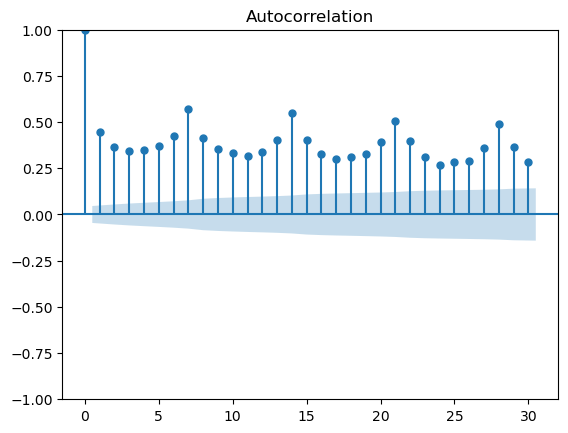

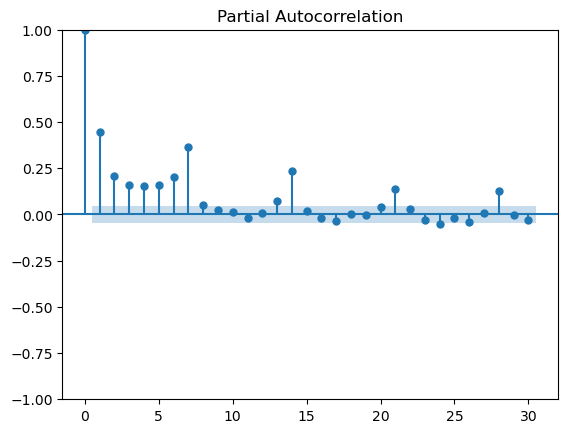

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train_df['sales'],lags=30);
plot_pacf(train_df['sales'],lags=30);

In [7]:
##as the ADFuller test indicates that the seies is stationary yet ACF shows 7 day seasonal trend , 
# we will try 7 day differencing to remove the seasonality and make the series more stationary.

train_df['sales_7_diff'] = train_df['sales'] - train_df['sales'].shift(7)

In [8]:
train_df.head(20)

,sales,sales_7_diff
date,,
2013-01-01,13,NaN
2013-01-02,11,NaN
2013-01-03,14,NaN
2013-01-04,13,NaN
2013-01-05,10,NaN
2013-01-06,12,NaN
2013-01-07,10,NaN
2013-01-08,9,-4.0
2013-01-09,12,1.0


In [9]:
test_stationarity(train_df['sales_7_diff'].dropna())

ADF statistics : -8.94440736006787
p-value : 9.07014941005302e-15
The series is stationary


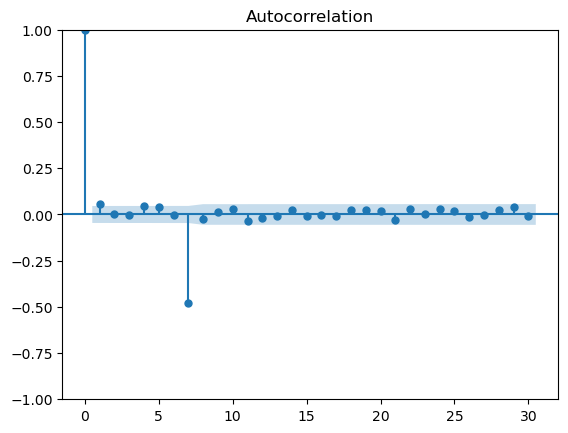

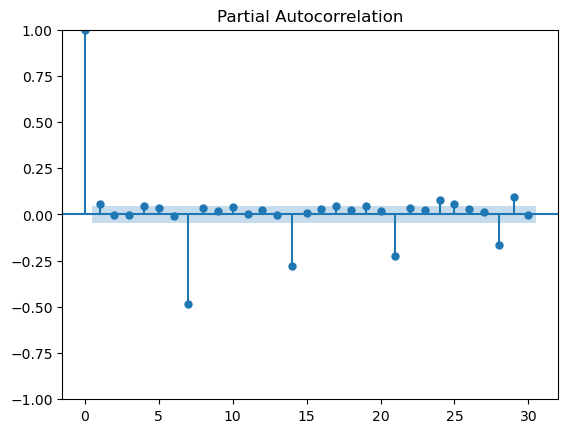

In [10]:
plot_acf(train_df['sales_7_diff'].dropna(),lags=30);
plot_pacf(train_df['sales_7_diff'].dropna(),lags=30);

In [11]:
split_point = int(len(train_df)*0.8)
train_data = train_df['sales'].iloc[:split_point]
test_data = train_df['sales'].iloc[split_point:]

In [12]:
train_data.tail()

date
2016-12-26    16
2016-12-27    10
2016-12-28    16
2016-12-29    21
2016-12-30    24
Name: sales, dtype: int64

In [13]:
test_data.head()

date
2016-12-31    14
2017-01-01    19
2017-01-02    15
2017-01-03    10
2017-01-04    16
Name: sales, dtype: int64

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model = SARIMAX(train_data,order =(1, 0, 1), seasonal_order = (1,1,1,7))
model_fit = model.fit()


/Users/home/softwares/anaconda3/envs/requirements/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/home/softwares/anaconda3/envs/requirements/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                             sales   No. Observations:                 1460
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -4284.681
Date:                           Sat, 14 Mar 2026   AIC                           8579.362
Time:                                   13:53:34   BIC                           8605.769
Sample:                               01-01-2013   HQIC                          8589.216
                                    - 12-30-2016                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9941      0.004    248.971      0.000       0.986       1.002
ma.L1         -0.8875      0.014    -61.376      0.000      -0.916      -0.859
ar.S.L7        0.0332      0.026      1.287      0.198      -0.017       0.084
ma.S.L7       -0.9970      0.016    -62.054      0.000      -1.028      -0.965
sigma2        20.8930      0.741     28.177      0.000      19.440      22.346
===================================================================================
Ljung-Box (L1) (Q):                   0.33   Jarque-Bera (JB):                13.05
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):               1.35   Skew:                             0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
from pmdarima import auto_arima

auto_model = auto_arima(train_data,seasonal=True,m=7)

auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 1460
Model:             SARIMAX(2, 1, 3)x(0, 0, [1], 7)   Log Likelihood               -4383.015
Date:                             Sat, 14 Mar 2026   AIC                           8780.030
Time:                                     14:00:35   BIC                           8817.028
Sample:                                 01-01-2013   HQIC                          8793.832
                                      - 12-30-2016                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2447      0.003    409.792      0.000       1.239       1.251
ar.L2         -0.9946      0.003   -335.476      0.000      -1.000      -0.989
ma.L1         -2.1513      0.015   -144.477      0.000      -2.180      -2.122
ma.L2          2.1055      0.022     95.737      0.000       2.062       2.149
ma.L3         -0.8844      0.015    -59.515      0.000      -0.913      -0.855
ma.S.L7        0.1374      0.025      5.409      0.000       0.088       0.187
sigma2        23.4249      0.794     29.518      0.000      21.870      24.980
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                15.31
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               1.44   Skew:                             0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
prediction_once = auto_model.predict(n_periods=len(test_data))

In [18]:
## rolling prediction

prediction_rolling = []

for test_row in test_data:
    pred = auto_model.predict(n_preriods=1)[0]
    prediction_rolling.append(pred)

    auto_model.update(test_row)



/var/folders/7d/x7r1lx_57rngyl_mcpz1qfd80000gr/T/ipykernel_42987/3151382586.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = auto_model.predict(n_preriods=1)[0]


Mean absolute error for all at once prediction : 6.434141982324583
Root mean squared error for all at once prediction : 8.15233531186924
Mean absolute percentage error for all at once prediction : 0.28404327994835865
R2 score for all at once prediction : -0.37695417895199723
Mean absolute error for rolling prediction : 4.265478092508979
Root mean squared error for rolling prediction : 5.3384892396401895
Mean absolute percentage error for all at once prediction : 0.22504760547216746
R2 score for rolling prediction : 0.40953771432782937


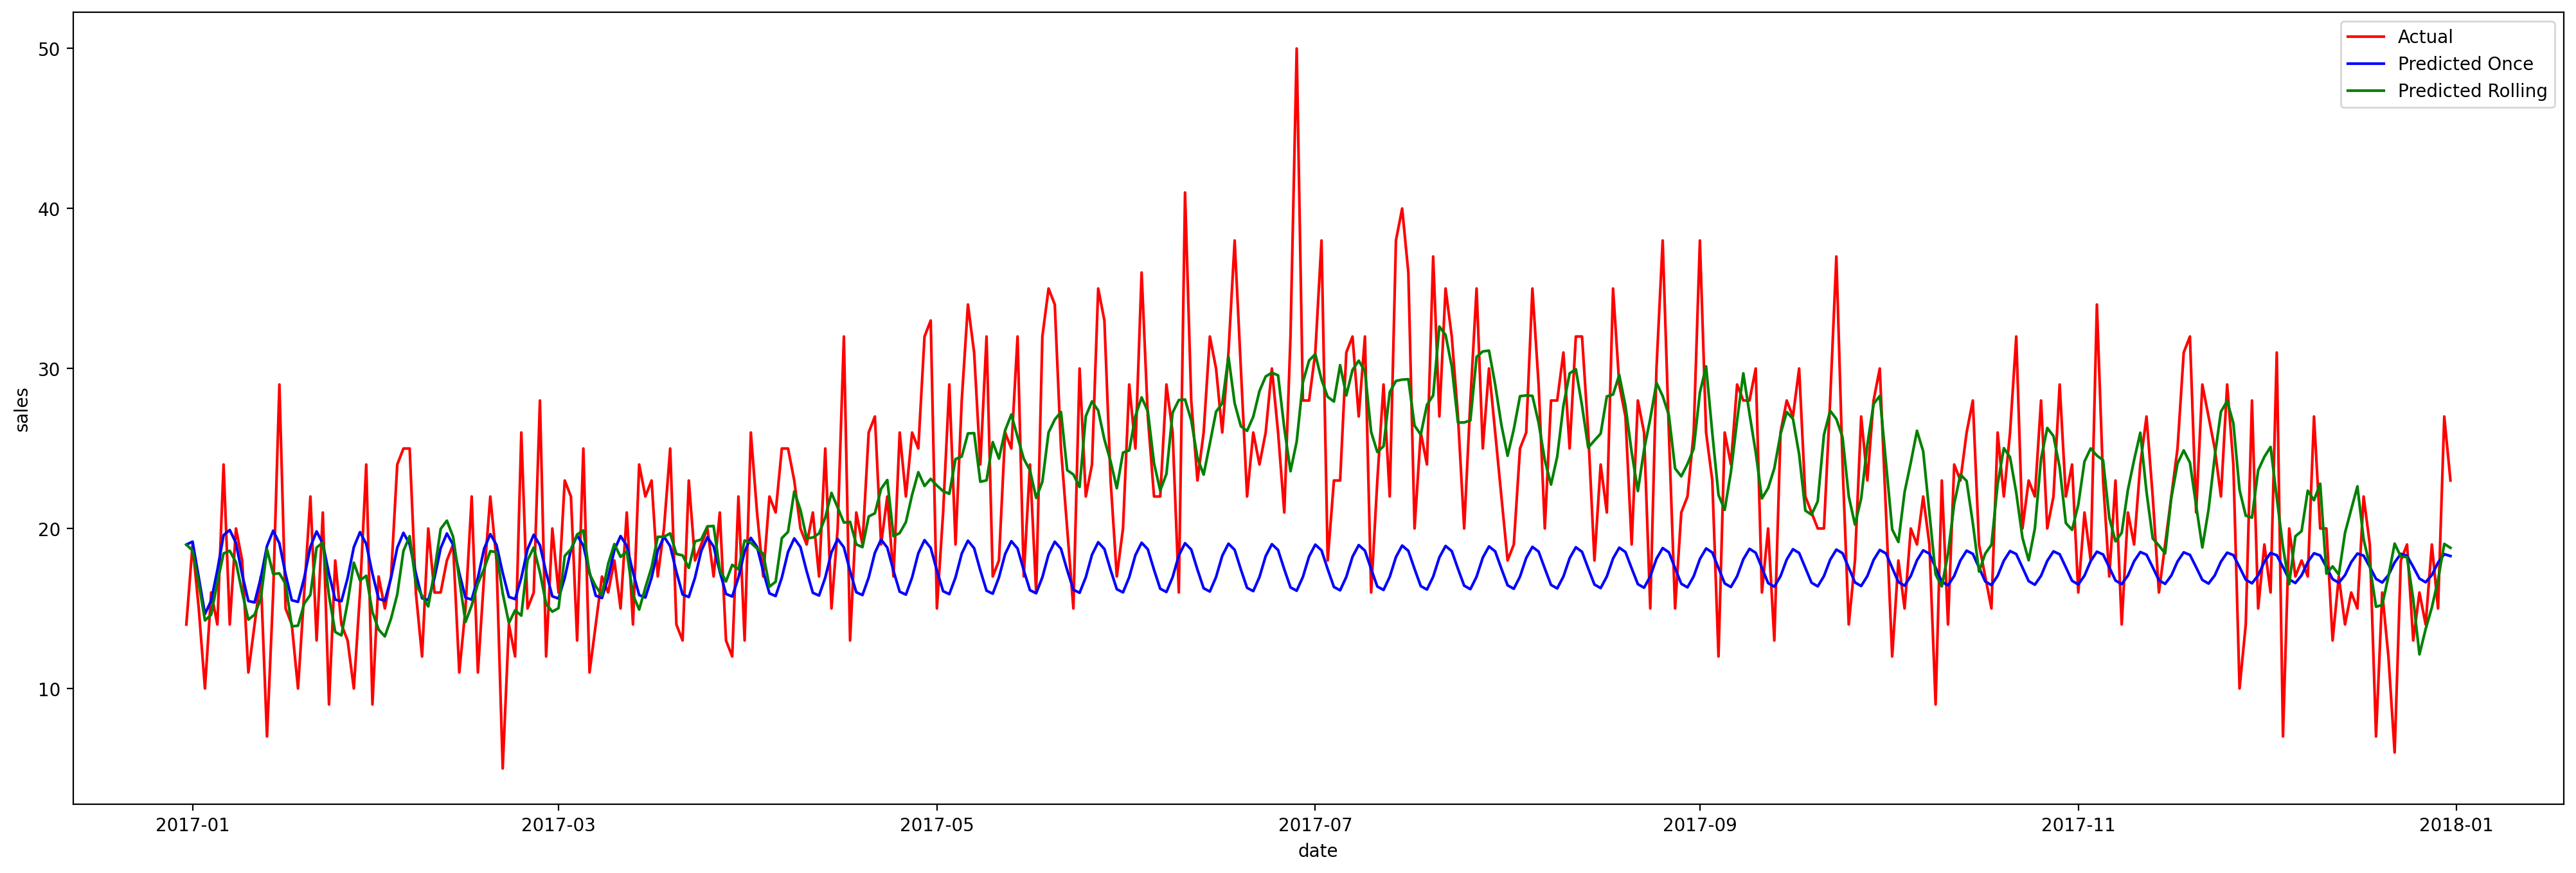

In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_absolute_percentage_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns

mae = mean_absolute_error(test_data,prediction_once)
print(f"Mean absolute error for all at once prediction : {mae}")
rmse = root_mean_squared_error(test_data,prediction_once)
print(f"Root mean squared error for all at once prediction : {rmse}")
mape = mean_absolute_percentage_error(test_data,prediction_once)
print(f"Mean absolute percentage error for all at once prediction : {mape}")
r2 = r2_score(test_data,prediction_once)
print(f"R2 score for all at once prediction : {r2}")


mae = mean_absolute_error(test_data,prediction_rolling)
print(f"Mean absolute error for rolling prediction : {mae}")
rmse = root_mean_squared_error(test_data,prediction_rolling)
print(f"Root mean squared error for rolling prediction : {rmse}")
mape = mean_absolute_percentage_error(test_data,prediction_rolling)
print(f"Mean absolute percentage error for all at once prediction : {mape}")
r2 = r2_score(test_data,prediction_rolling)
print(f"R2 score for rolling prediction : {r2}")


plt.figure(figsize=(25,8),dpi=200)
sns.lineplot(x=test_data.index, y=test_data, color='red', label='Actual')
sns.lineplot(x=test_data.index, y=prediction_once, color='blue', label='Predicted Once')
sns.lineplot(x=test_data.index, y=prediction_rolling, color='green', label='Predicted Rolling')
plt.legend()
plt.show()